In [1]:
!pip install kaggle -q

In [2]:
import os
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)

KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')

with open('/root/.kaggle/kaggle.json', 'w') as f:
  f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API credentials configured.")

Kaggle API credentials configured.


In [3]:
kaggle_dataset_path = 'aesika/english-premier-league-player-stats-2425'

import os
dataset_dir = './english-premier-league-player-stats-2425'
os.makedirs(dataset_dir, exist_ok=True)

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

print(f"Downloading dataset: {kaggle_dataset_path} to {dataset_dir}")
api.dataset_download_files(kaggle_dataset_path, path=dataset_dir, unzip=True)
print("Dataset downloaded and unzipped successfully!")

print("Files in the downloaded dataset directory:")
for root, dirs, files in os.walk(dataset_dir):
  for file in files:
    print(os.path.join(root, file))

Dataset URL: https://www.kaggle.com/datasets/aesika/english-premier-league-player-stats-2425
Dataset downloaded and unzipped successfully!
Files in the downloaded dataset directory:
./english-premier-league-player-stats-2425/epl_player_stats_24_25.csv


## feature engineering

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
data = pd.read_csv("/content/english-premier-league-player-stats-2425/epl_player_stats_24_25.csv")

data.head()

,Player Name,Club,Nationality,Position,Appearances,Minutes,Goals,Assists,Shots,Shots On Target,...,Fouls,Yellow Cards,Red Cards,Saves,Saves %,Penalties Saved,Clearances Off Line,Punches,High Claims,Goals Prevented
0,Ben White,Arsenal,England,DEF,17,1198,0,2,9,12,...,10,2,0,0,0%,0,0,0,0,0.0
1,Bukayo Saka,Arsenal,England,MID,25,1735,6,10,67,2,...,15,3,0,0,0%,0,0,0,0,0.0
2,David Raya,Arsenal,Spain,GKP,38,3420,0,0,0,0,...,1,3,0,86,72%,0,0,8,53,2.1
3,Declan Rice,Arsenal,England,MID,35,2833,4,7,48,18,...,21,5,1,0,0%,0,0,0,0,0.0
4,Ethan Nwaneri,Arsenal,England,MID,26,889,4,0,24,0,...,9,1,0,0,0%,0,0,0,0,0.0


In [6]:
df = data.copy()

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)

Numerical columns: 46
Categorical columns: 11

Categorical columns:
['Player Name', 'Club', 'Nationality', 'Position', 'Conversion %', 'Passes%', 'Crosses %', 'fThird Passes %', 'gDuels %', 'aDuels %', 'Saves %']

Numerical columns:
['Appearances', 'Minutes', 'Goals', 'Assists', 'Shots', 'Shots On Target', 'Big Chances Missed', 'Hit Woodwork', 'Offsides', 'Touches', 'Passes', 'Successful Passes', 'Crosses', 'Successful Crosses', 'fThird Passes', 'Successful fThird Passes', 'Through Balls', 'Carries', 'Progressive Carries', 'Carries Ended with Goal', 'Carries Ended with Assist', 'Carries Ended with Shot', 'Carries Ended with Chance', 'Possession Won', 'Dispossessed', 'Clean Sheets', 'Clearances', 'Interceptions', 'Blocks', 'Tackles', 'Ground Duels', 'gDuels Won', 'Aerial Duels', 'aDuels Won', 'Goals Conceded', 'xGoT Conceded', 'Own Goals', 'Fouls', 'Yellow Cards', 'Red Cards', 'Saves', 'Penalties Saved', 'Clearances Off Line', 'Punches', 'High Claims', 'Goals Prevented']


In [8]:
drop_cols = ["Player Name", "Club", "Nationality"]

In [9]:
y = df["Position"]

In [10]:
percentage_cols = [
    "Conversion %",
    "Passes%",
    "Crosses %",
    "fThird Passes %",
    "gDuels %",
    "aDuels %",
    "Saves %"
]

for col in percentage_cols:
    df[col] = (
        df[col]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

In [11]:
df[percentage_cols].head()

,Conversion %,Passes%,Crosses %,fThird Passes %,gDuels %,aDuels %,Saves %
0,13.0,89.0,20.0,83.0,50.0,31.0,0.0
1,25.0,87.0,0.0,60.0,59.0,51.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,72.0
3,15.0,81.0,11.0,76.0,35.0,39.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0


These are count-based statistics that accumulate as a player spends more time on the pitch. We will convert them into per-90 rates so that players with different amounts of playing time can be compared more fairly.

In [12]:
(df["Minutes"] == 0).sum()

np.int64(0)

In [13]:
per90_cols = [
    "Goals",
    "Assists",
    "Shots",
    "Shots On Target",
    "Big Chances Missed",
    "Hit Woodwork",
    "Offsides",
    "Touches",
    "Passes",
    "Successful Passes",
    "Crosses",
    "Successful Crosses",
    "fThird Passes",
    "Successful fThird Passes",
    "Through Balls",
    "Carries",
    "Progressive Carries",
    "Carries Ended with Goal",
    "Carries Ended with Assist",
    "Carries Ended with Shot",
    "Carries Ended with Chance",
    "Possession Won",
    "Dispossessed",
    "Clean Sheets",
    "Clearances",
    "Interceptions",
    "Blocks",
    "Tackles",
    "Ground Duels",
    "gDuels Won",
    "Aerial Duels",
    "aDuels Won",
    "Goals Conceded",
    "xGoT Conceded",
    "Own Goals",
    "Fouls",
    "Yellow Cards",
    "Red Cards",
    "Saves",
    "Penalties Saved",
    "Clearances Off Line",
    "Punches",
    "High Claims",
    "Goals Prevented"
]

In [14]:
for col in per90_cols:
  df[f"{col}_per90"] = (df[col] / df["Minutes"]) * 90

In [15]:
per90_feature_cols = [f"{col}_per90" for col in per90_cols]

df[per90_feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Goals_per90,562.0,0.102201,0.178318,0.000000,0.000000,0.000000,0.136367,1.730769
Assists_per90,562.0,0.059281,0.107943,0.000000,0.000000,0.000000,0.091279,0.666667
Shots_per90,562.0,1.432134,4.124172,0.000000,0.270485,0.799445,1.871787,90.000000
Shots On Target_per90,562.0,0.263396,0.474382,0.000000,0.000000,0.028311,0.352611,4.316997
Big Chances Missed_per90,562.0,0.134564,0.232141,0.000000,0.000000,0.028723,0.173265,1.914894
Hit Woodwork_per90,562.0,0.057644,0.636668,0.000000,0.000000,0.000000,0.033475,15.000000
Offsides_per90,562.0,0.157692,0.326133,0.000000,0.000000,0.029143,0.188029,4.285714
Touches_per90,562.0,64.518271,48.392832,0.000000,46.054884,58.638585,71.839941,810.000000
Passes_per90,562.0,24.393134,31.594375,0.000000,0.000000,11.812563,41.407152,151.833509
Successful Passes_per90,562.0,20.754435,27.619418,0.000000,0.000000,9.099522,35.297123,136.675532


In [16]:
data[per90_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Goals,562.0,1.713523,3.310674,0.0,0.00,0.0,2.00,29.0
Assists,562.0,1.145907,2.197891,0.0,0.00,0.0,2.00,18.0
Shots,562.0,17.526690,22.342341,0.0,1.00,10.0,25.00,130.0
Shots On Target,562.0,5.514235,9.407054,0.0,0.00,1.0,7.00,61.0
Big Chances Missed,562.0,2.135231,3.732051,0.0,0.00,1.0,3.00,27.0
Hit Woodwork,562.0,0.496441,0.986986,0.0,0.00,0.0,1.00,6.0
Offsides,562.0,2.250890,4.085456,0.0,0.00,1.0,3.00,28.0
Touches,562.0,857.033808,729.009027,0.0,199.25,700.5,1356.75,3347.0
Passes,562.0,502.857651,602.870544,0.0,0.00,304.5,895.25,2923.0
Successful Passes,562.0,427.012456,525.788461,0.0,0.00,230.5,753.00,2680.0


We inspect players with the lowest playing time to understand the source of extreme per-90 values. Players with very few minutes can produce unusually large rates because a small number of events is extrapolated to a full 90-minute period.

In [17]:
df[["Player Name", "Club", "Position", "Minutes", "Shots"]].sort_values("Minutes").head(10)

,Player Name,Club,Position,Minutes,Shots
558,Tom King,Wolverhampton Wanderers,GKP,1,0
547,Mateus Mané,Wolverhampton Wanderers,MID,1,0
359,Vitor Reis,Manchester City,DEF,1,0
294,Michael Golding,Leicester City,MID,1,0
303,Will Alves,Leicester City,FWD,1,0
516,Kaelan Casey,West Ham United,DEF,1,0
296,Olabade Aluko,Leicester City,DEF,1,0
230,Jay Stansfield,Fulham,FWD,1,0
80,Zain Silcott-Duberry,Bournemouth,FWD,1,0
77,Remy Rees-Dottin,Bournemouth,FWD,1,0


In [18]:
df[["Player Name","Club","Position","Minutes","Shots","Shots_per90"]].sort_values("Minutes").head(10)

,Player Name,Club,Position,Minutes,Shots,Shots_per90
558,Tom King,Wolverhampton Wanderers,GKP,1,0,0.0
547,Mateus Mané,Wolverhampton Wanderers,MID,1,0,0.0
359,Vitor Reis,Manchester City,DEF,1,0,0.0
294,Michael Golding,Leicester City,MID,1,0,0.0
303,Will Alves,Leicester City,FWD,1,0,0.0
516,Kaelan Casey,West Ham United,DEF,1,0,0.0
296,Olabade Aluko,Leicester City,DEF,1,0,0.0
230,Jay Stansfield,Fulham,FWD,1,0,0.0
80,Zain Silcott-Duberry,Bournemouth,FWD,1,0,0.0
77,Remy Rees-Dottin,Bournemouth,FWD,1,0,0.0


We examine the players with the highest shots per 90 and compare their rates with their actual minutes and shot totals. This helps us determine whether extreme values represent genuine performance or are artifacts caused by very small sample sizes.

In [19]:
df[["Player Name", "Club", "Position", "Minutes", "Shots", "Shots_per90"]].sort_values("Shots_per90", ascending=False).head(10)

,Player Name,Club,Position,Minutes,Shots,Shots_per90
162,Shumaira Mheuka,Chelsea,FWD,1,1,90.000000
168,Asher Agbinone,Crystal Palace,FWD,4,1,22.500000
22,Takehiro Tomiyasu,Arsenal,DEF,6,1,15.000000
17,Nathan Butler-Oyedeji,Arsenal,FWD,6,1,15.000000
187,Matheus França,Crystal Palace,MID,52,6,10.384615
225,Carlos Vinícius,Fulham,MID,13,1,6.923077
218,Youssef Chermiti,Everton,FWD,42,3,6.428571
60,Enes Ünal,Bournemouth,FWD,331,20,5.438066
386,Scott McTominay,Manchester United,MID,17,1,5.294118
70,Luis Sinisterra,Bournemouth,MID,230,13,5.086957


We examine how many players meet the minimum playing-time threshold of 450 minutes.

In [20]:
print("Total players:", len(df))

players_450 = df[df["Minutes"] >= 450]

print("Players with >= 450 minutes:", len(players_450))
print("Players excluded:", len(df) - len(players_450))

Total players: 562
Players with >= 450 minutes: 397
Players excluded: 165


We create a separate modeling dataset containing only players who played at least 450 minutes (5 matches).

In [21]:
df_model = df[df["Minutes"] >= 450].copy()

df_model["Minutes"].describe()

,Minutes
count,397.000000
mean,1828.541562
std,861.306728
min,450.000000
25%,1064.000000
50%,1781.000000
75%,2570.000000
max,3420.000000


In [22]:
df_model["Position"].value_counts()

,count
Position,
MID,174
DEF,144
FWD,46
GKP,33


In [23]:
per90_feature_cols

['Goals_per90',
 'Assists_per90',
 'Shots_per90',
 'Shots On Target_per90',
 'Big Chances Missed_per90',
 'Hit Woodwork_per90',
 'Offsides_per90',
 'Touches_per90',
 'Passes_per90',
 'Successful Passes_per90',
 'Crosses_per90',
 'Successful Crosses_per90',
 'fThird Passes_per90',
 'Successful fThird Passes_per90',
 'Through Balls_per90',
 'Carries_per90',
 'Progressive Carries_per90',
 'Carries Ended with Goal_per90',
 'Carries Ended with Assist_per90',
 'Carries Ended with Shot_per90',
 'Carries Ended with Chance_per90',
 'Possession Won_per90',
 'Dispossessed_per90',
 'Clean Sheets_per90',
 'Clearances_per90',
 'Interceptions_per90',
 'Blocks_per90',
 'Tackles_per90',
 'Ground Duels_per90',
 'gDuels Won_per90',
 'Aerial Duels_per90',
 'aDuels Won_per90',
 'Goals Conceded_per90',
 'xGoT Conceded_per90',
 'Own Goals_per90',
 'Fouls_per90',
 'Yellow Cards_per90',
 'Red Cards_per90',
 'Saves_per90',
 'Penalties Saved_per90',
 'Clearances Off Line_per90',
 'Punches_per90',
 'High Claims_p

In [24]:
percentage_cols

['Conversion %',
 'Passes%',
 'Crosses %',
 'fThird Passes %',
 'gDuels %',
 'aDuels %',
 'Saves %']

In [25]:
feature_cols = per90_feature_cols + percentage_cols

X = df_model[feature_cols]
y = df_model["Position"]

print("Number of features:", X.shape[1])
print("Number of players:", X.shape[0])

Number of features: 51
Number of players: 397


In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (397, 51)
y shape: (397,)


Stratification ensures that the proportion of DEF, MID, FWD, and GKP players remains approximately the same in both sets.

In [27]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [28]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (317, 51)
Test set: (80, 51)


In [29]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training distribution:
Position
MID    139
DEF    115
FWD     37
GKP     26
Name: count, dtype: int64

Test distribution:
Position
MID    35
DEF    29
FWD     9
GKP     7
Name: count, dtype: int64


In [30]:
X_train.describe().T[["mean", "std", "min", "max"]].head(15)

,mean,std,min,max
Goals_per90,0.122935,0.166853,0.000000,1.006390
Assists_per90,0.077337,0.112291,0.000000,0.531496
Shots_per90,1.205478,0.989546,0.000000,4.456869
Shots On Target_per90,0.352970,0.502300,0.000000,3.214286
Big Chances Missed_per90,0.142146,0.190823,0.000000,1.080000
Hit Woodwork_per90,0.032359,0.053455,0.000000,0.252454
Offsides_per90,0.158351,0.219583,0.000000,1.343284
Touches_per90,57.953160,15.112079,20.003522,104.341463
Passes_per90,34.615099,33.119701,0.000000,151.833509
Successful Passes_per90,29.540396,29.194416,0.000000,136.675532


## model

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

class_weight="balanced" tells Random Forest to give more importance to mistakes on underrepresented classes.

In [32]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=1000,
            random_state=42
        ))
    ])
}

In [33]:
for name, pipeline in models.items():
  pipeline.fit(X_train, y_train)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.
MLP Neural Network trained successfully.


In [34]:
predictions = {}

for name, pipeline in models.items():
  predictions[name] = pipeline.predict(X_test)

print("Predictions generated for all models.")

Predictions generated for all models.


In [35]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

In [36]:
results = []

for name, y_pred in predictions.items():
  results.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(
          y_test, y_pred, average="macro", zero_division=0
      ),
      "Recall": recall_score(
          y_test, y_pred, average="macro", zero_division=0
      ),
      "F1": f1_score(
          y_test, y_pred, average="macro", zero_division=0
      )
  })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.8625,0.892601,0.874247,0.878868
1,Gradient Boosting,0.8250,0.843658,0.852819,0.846078
2,Logistic Regression,0.8125,0.833178,0.825041,0.824819
3,MLP Neural Network,0.7625,0.767560,0.797947,0.777728


In [37]:
for name, y_pred in predictions.items():
  print("=" * 70)
  print(name)
  print("=" * 70)

  print(classification_report(y_test,y_pred,zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

         DEF       0.81      0.86      0.83        29
         FWD       0.86      0.67      0.75         9
         GKP       0.88      1.00      0.93         7
         MID       0.79      0.77      0.78        35

    accuracy                           0.81        80
   macro avg       0.83      0.83      0.82        80
weighted avg       0.81      0.81      0.81        80

Random Forest
              precision    recall  f1-score   support

         DEF       0.86      0.86      0.86        29
         FWD       1.00      0.78      0.88         9
         GKP       0.88      1.00      0.93         7
         MID       0.83      0.86      0.85        35

    accuracy                           0.86        80
   macro avg       0.89      0.87      0.88        80
weighted avg       0.87      0.86      0.86        80

Gradient Boosting
              precision    recall  f1-score   support

         DEF       0.81

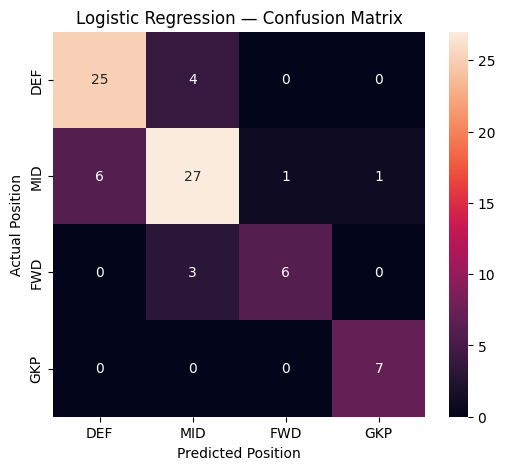

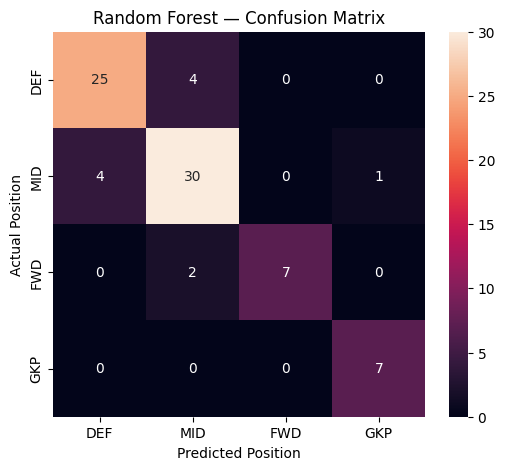

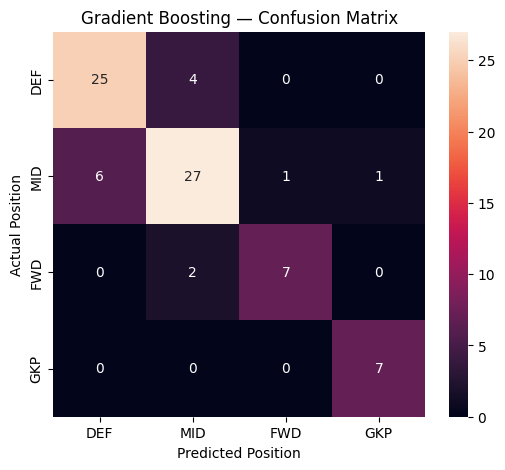

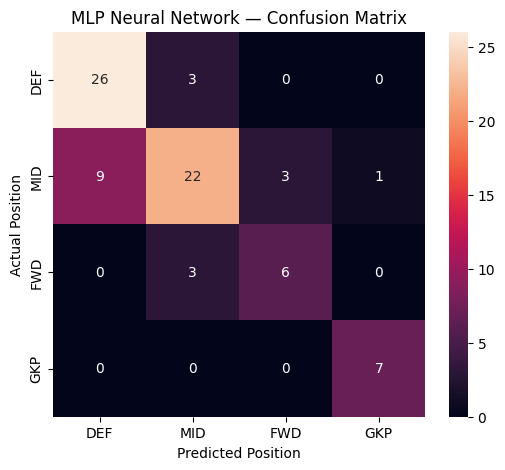

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, y_pred in predictions.items():
  cm = confusion_matrix(
      y_test,
      y_pred,
      labels=["DEF", "MID", "FWD", "GKP"]
  )

  plt.figure(figsize=(6, 5))

  sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      xticklabels=["DEF", "MID", "FWD", "GKP"],
      yticklabels=["DEF", "MID", "FWD", "GKP"]
  )

  plt.title(f"{name} — Confusion Matrix")
  plt.xlabel("Predicted Position")
  plt.ylabel("Actual Position")
  plt.show()

In [39]:
best_model_name = results_df.sort_values(
    "F1",
    ascending=False
).iloc[0]["Model"]

print("Best model based on Macro F1:", best_model_name)

Best model based on Macro F1: Random Forest


## trying to optimize

In [40]:
rf_model = models["Random Forest"].named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,Clearances_per90,0.104069
1,Touches_per90,0.095323
2,Shots_per90,0.092514
3,Dispossessed_per90,0.086323
4,Saves_per90,0.061409
5,Tackles_per90,0.057725
6,Fouls_per90,0.055420
7,Offsides_per90,0.047153
8,Big Chances Missed_per90,0.043438
9,High Claims_per90,0.042850


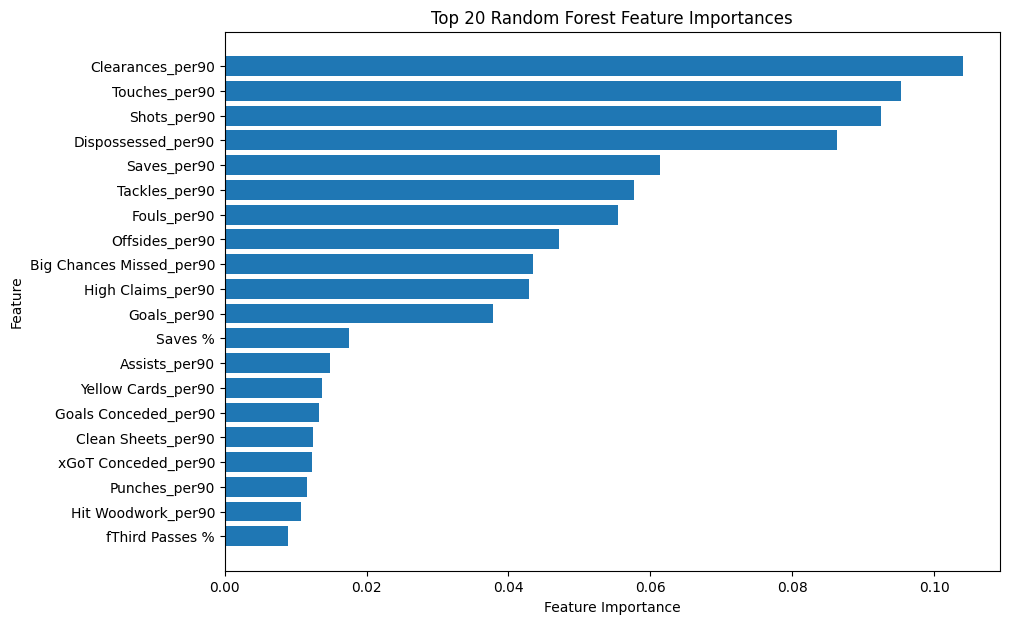

In [41]:
top_features = feature_importance.head(20).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.show()

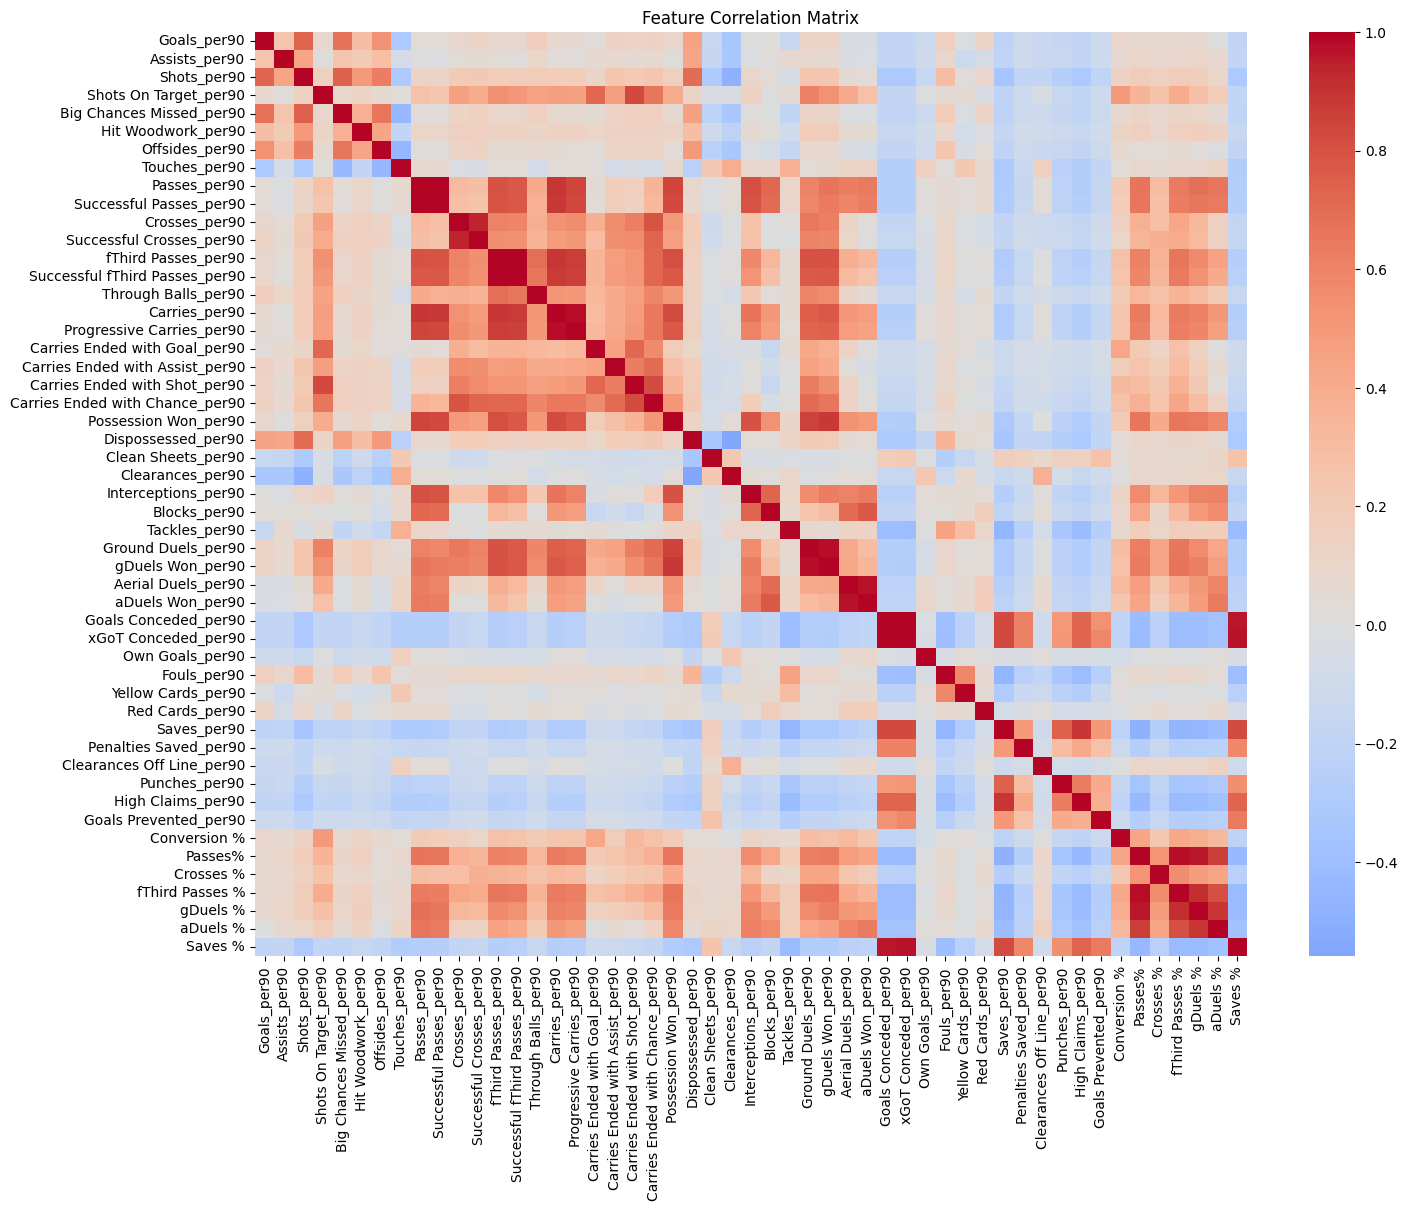

In [42]:
corr_matrix = X_train.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [43]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

corr_pairs["Absolute Correlation"] = (
    corr_pairs["Correlation"].abs()
)

corr_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
).head(20)

,Feature 1,Feature 2,Correlation,Absolute Correlation
1104,Goals Conceded_per90,xGoT Conceded_per90,0.997529,0.997529
372,Passes_per90,Successful Passes_per90,0.997429,0.997429
534,fThird Passes_per90,Successful fThird Passes_per90,0.990741,0.990741
645,Carries_per90,Progressive Carries_per90,0.980616,0.980616
1022,Ground Duels_per90,gDuels Won_per90,0.979707,0.979707
1261,Passes%,fThird Passes %,0.977288,0.977288
1138,xGoT Conceded_per90,Saves %,0.968425,0.968425
1065,Aerial Duels_per90,aDuels Won_per90,0.965798,0.965798
1262,Passes%,gDuels %,0.962329,0.962329
1121,Goals Conceded_per90,Saves %,0.960347,0.960347


We identify feature pairs with an absolute correlation of at least 0.95. These pairs contain highly similar information and are candidates for feature reduction. We will test whether removing redundant features improves or maintains model performance.

In [44]:
high_corr = corr_pairs[
    corr_pairs["Absolute Correlation"] >= 0.95
]

high_corr

,Feature 1,Feature 2,Correlation,Absolute Correlation
372,Passes_per90,Successful Passes_per90,0.997429,0.997429
534,fThird Passes_per90,Successful fThird Passes_per90,0.990741,0.990741
645,Carries_per90,Progressive Carries_per90,0.980616,0.980616
1022,Ground Duels_per90,gDuels Won_per90,0.979707,0.979707
1065,Aerial Duels_per90,aDuels Won_per90,0.965798,0.965798
1104,Goals Conceded_per90,xGoT Conceded_per90,0.997529,0.997529
1121,Goals Conceded_per90,Saves %,0.960347,0.960347
1138,xGoT Conceded_per90,Saves %,0.968425,0.968425
1261,Passes%,fThird Passes %,0.977288,0.977288
1262,Passes%,gDuels %,0.962329,0.962329


In [45]:
importance_dict = dict(
    zip(feature_importance["Feature"], feature_importance["Importance"])
)

features_to_remove = set()

for _, row in high_corr.iterrows():
    f1 = row["Feature 1"]
    f2 = row["Feature 2"]

    if importance_dict[f1] >= importance_dict[f2]:
        features_to_remove.add(f2)
    else:
        features_to_remove.add(f1)

print("Features to remove:", len(features_to_remove))
print("\nFeatures:")
print(sorted(features_to_remove))

Features to remove: 9

Features:
['Aerial Duels_per90', 'Carries_per90', 'Goals Conceded_per90', 'Ground Duels_per90', 'Passes%', 'Successful Passes_per90', 'fThird Passes_per90', 'gDuels %', 'xGoT Conceded_per90']


In [46]:
reduced_features = [
    col for col in X_train.columns
    if col not in features_to_remove
]

X_train_reduced = X_train[reduced_features]
X_test_reduced = X_test[reduced_features]

print("Original number of features:", X_train.shape[1])
print("Reduced number of features:", X_train_reduced.shape[1])

Original number of features: 51
Reduced number of features: 42


In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_pipeline = models["Random Forest"]

baseline_cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

print("Baseline Random Forest")
print("CV scores:", baseline_cv_scores)
print("Mean Macro F1:", baseline_cv_scores.mean())
print("Std:", baseline_cv_scores.std())

Baseline Random Forest
CV scores: [0.81428823 0.91655844 0.84181818 0.75395981 0.79461684]
Mean Macro F1: 0.824248300552011
Std: 0.054309411840510365


In [48]:
rf_reduced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

reduced_cv_scores = cross_val_score(
    rf_reduced,
    X_train_reduced,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

print("Reduced-feature Random Forest")
print("CV scores:", reduced_cv_scores)
print("Mean Macro F1:", reduced_cv_scores.mean())
print("Std:", reduced_cv_scores.std())

Reduced-feature Random Forest
CV scores: [0.84223771 0.91655844 0.84181818 0.77293144 0.79529361]
Mean Macro F1: 0.8337678772617085
Std: 0.04933997131902831


In [49]:
print("FEATURE REDUCTION COMPARISON")

print(
    f"Original features: {X_train.shape[1]} "
    f"| CV Macro F1: {baseline_cv_scores.mean():.4f}"
)

print(
    f"Reduced features:  {X_train_reduced.shape[1]} "
    f"| CV Macro F1: {reduced_cv_scores.mean():.4f}"
)

difference = (
    reduced_cv_scores.mean() -
    baseline_cv_scores.mean()
)

print(f"\nChange in Macro F1: {difference:+.4f}")

FEATURE REDUCTION COMPARISON
Original features: 51 | CV Macro F1: 0.8242
Reduced features:  42 | CV Macro F1: 0.8338

Change in Macro F1: +0.0095


## random forest hyperparameter search

In [50]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

In [51]:
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(
    X_train_reduced,
    y_train
)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                             20, 30],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, return_train_score=True,
                   scoring='f1_macro')

In [52]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV Macro F1:")
print(random_search.best_score_)

Best parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}

Best CV Macro F1:
0.8583022976781685


In [53]:
cv_results = pd.DataFrame(random_search.cv_results_)

results = cv_results[
    [
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "params"
    ]
].sort_values("rank_test_score")

results.head(10)

,mean_test_score,std_test_score,rank_test_score,params
21,0.858302,0.033191,1,"{'model__n_estimators': 500, 'model__min_sampl..."
15,0.852153,0.039795,2,"{'model__n_estimators': 500, 'model__min_sampl..."
29,0.850995,0.040969,3,"{'model__n_estimators': 500, 'model__min_sampl..."
14,0.850995,0.040969,3,"{'model__n_estimators': 500, 'model__min_sampl..."
25,0.848983,0.051385,5,"{'model__n_estimators': 300, 'model__min_sampl..."
23,0.847683,0.049957,6,"{'model__n_estimators': 300, 'model__min_sampl..."
22,0.842930,0.048891,7,"{'model__n_estimators': 200, 'model__min_sampl..."
12,0.842548,0.042649,8,"{'model__n_estimators': 200, 'model__min_sampl..."
11,0.841454,0.038304,9,"{'model__n_estimators': 200, 'model__min_sampl..."
10,0.841454,0.038304,9,"{'model__n_estimators': 200, 'model__min_sampl..."


In [54]:
best_index = random_search.best_index_

print("BEST MODEL")
print("Best parameters:")
print(random_search.best_params_)

print("\nMean training Macro F1:")
print(random_search.cv_results_["mean_train_score"][best_index])

print("\nMean validation Macro F1:")
print(random_search.cv_results_["mean_test_score"][best_index])

print("\nValidation standard deviation:")
print(random_search.cv_results_["std_test_score"][best_index])

BEST MODEL
Best parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}

Mean training Macro F1:
0.9879519912862497

Mean validation Macro F1:
0.8583022976781685

Validation standard deviation:
0.03319119934114365


In [55]:
rf_regularized = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_features="log2",
        class_weight="balanced",
        random_state=42
    ))
])

regularization_grid = {
    "model__max_depth": [5, 8, 10, 12, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4, 6, 10]
}

In [56]:
regularized_search = RandomizedSearchCV(
    rf_regularized,
    param_distributions=regularization_grid,
    n_iter=25,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

regularized_search.fit(
    X_train_reduced,
    y_train
)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     max_features='log2',
                                                                     n_estimators=500,
                                                                     random_state=42))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 8, 10, 12, 15,
                                                             20, None],
                                        'model__min_samples_leaf': [1, 2, 4, 6,
                                                                    10],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     15]},
                   random_state=42, return_train_score=True,
                   scoring='f1_macro')

In [57]:
best_idx = regularized_search.best_index_

print("REGULARIZED RANDOM FOREST")

print("Best parameters:")
print(regularized_search.best_params_)

print("\nTraining Macro F1:")
print(regularized_search.cv_results_["mean_train_score"][best_idx])

print("\nValidation Macro F1:")
print(regularized_search.best_score_)

print("\nValidation Std:")
print(regularized_search.cv_results_["std_test_score"][best_idx])

REGULARIZED RANDOM FOREST
Best parameters:
{'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 20}

Training Macro F1:
0.9879519912862497

Validation Macro F1:
0.8583022976781685

Validation Std:
0.03319119934114365


In [58]:
best_rf = regularized_search.best_estimator_

best_rf.fit(X_train_reduced, y_train)

y_pred = best_rf.predict(X_test_reduced)

print("Test Macro F1:", f1_score(
    y_test,
    y_pred,
    average="macro"
))

Test Macro F1: 0.8710905972558515


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         DEF       0.83      0.86      0.85        29
         FWD       1.00      0.78      0.88         9
         GKP       0.88      1.00      0.93         7
         MID       0.83      0.83      0.83        35

    accuracy                           0.85        80
   macro avg       0.88      0.87      0.87        80
weighted avg       0.85      0.85      0.85        80



In [60]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

final_models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": best_rf,

    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=1000,
            random_state=42
        ))
    ])
}

In [61]:
results = []

for name, model in final_models.items():

    scores = cross_val_score(
        model,
        X_train_reduced,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Mean Macro F1": scores.mean(),
        "Std": scores.std()
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "Mean Macro F1",
    ascending=False
)

,Model,Mean Macro F1,Std
1,Random Forest,0.858302,0.033191
0,Logistic Regression,0.848295,0.052411
3,MLP Neural Network,0.846433,0.025503
2,Gradient Boosting,0.845340,0.064094


In this notebook, we performed feature engineering and built multiple supervised learning models to predict a player's **Position** using their Premier League 2024/25 statistics.

The feature engineering process included:
- Converting percentage-based columns from strings into numerical values.
- Creating **per-90 statistics** to normalize player statistics based on playing time.
- Checking for players with zero minutes before calculating per-90 features.
- Removing highly correlated and redundant features.
- Creating a final modelling dataset containing **397 players and 51 features** before feature reduction.
- Reducing the feature set from **51 to 42 features**, which improved the cross-validation Macro F1 from **0.8242 to 0.8338**.

We evaluated four supervised classification models:
- Logistic Regression
- Random Forest
- Gradient Boosting
- MLP Neural Network

Random Forest performed the best overall. After hyperparameter optimization using cross-validation, the best Random Forest achieved a validation **Macro F1 of 0.8583**. Its final performance on the unseen test set was a **Macro F1 of 0.8711** with an accuracy of approximately **85%**.

The final classification results showed particularly strong performance for **GKP, DEF, and FWD**, while MID was also classified with good performance.